# DELTA1 — A simple cross-asset time-series momentum CTA

**Objective.** Develop an explainable trading strategy using the supplied global futures/ETF data, with at least five years of out-of-sample evidence, a benchmark, visualisations, and explicit limitations.

**Answer.** I use a monthly 12-month time-series momentum rule across 22 USD-denominated futures, inverse-volatility position sizing, equal risk by asset class, and a 10% portfolio volatility target. The test period is **2005–2014**, an untouched 10.35-year window. Trading costs are included.

This notebook is fully reproducible from the provided CSVs. It is a historical research exercise, not investment advice.

## 1. Research motivation

The design follows three established findings:

1. [Moskowitz, Ooi & Pedersen (2012), *Time Series Momentum*](https://pages.stern.nyu.edu/~lpederse/papers/TimeSeriesMomentum.pdf) documents persistence in futures returns over roughly one to twelve months across equity indices, currencies, commodities, and bonds. The paper's 12-month direction rule motivates the signal used here.
2. [Hurst, Ooi & Pedersen (2017), *A Century of Evidence on Trend-Following Investing*](https://doi.org/10.3905/jpm.2017.44.1.015) reports long-run evidence across global markets and motivates broad asset-class diversification.
3. [Moreira & Muir (2017), *Volatility-Managed Portfolios*](https://www.nber.org/papers/w22208) motivates reducing exposure when realised volatility rises.

The implementation intentionally avoids a complex optimiser. The 12-month horizon is pre-specified from the literature, not chosen by maximising the 2005–2014 result.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

HERE = Path.cwd()
STRATEGY_DIR = HERE if (HERE / "delta1_cta.py").exists() else HERE / "delta1_strategy"
sys.path.insert(0, str(STRATEGY_DIR))

from delta1_cta import (
    ASSET_CLASSES,
    BacktestConfig,
    contribution_by_class,
    load_metadata,
    load_prices,
    performance_metrics,
    run_pipeline,
)

DATA_DIR = Path(os.environ.get(
    "DELTA1_DATA_DIR",
    str(STRATEGY_DIR / "data" / "Delta1"),
))
OUTPUT_DIR = STRATEGY_DIR / "outputs"

assert (DATA_DIR / "CATALOGUE_Delta1_Futures.csv").exists(), (
    "Set DELTA1_DATA_DIR to the supplied Delta1 folder."
)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Data and universe

I use the `_CCB` back-adjusted continuous contracts. These series remove mechanical roll gaps and are suitable for signal research, but the continuous ticker itself is not directly tradable.

The universe is deliberately restricted to contracts whose catalogue currency is USD. This keeps contract P&L in a common currency without introducing an unprovided historical FX-conversion assumption.

| Class | Contracts |
|---|---|
| Equity indices | ES, NQ, RTY, NKD |
| Government bonds | ZT, ZF, ZN, ZB |
| G10 FX | 6A, 6B, 6C, 6E, 6J, 6S |
| Commodities | CL, NG, GC, SI, HG, ZC, ZW, ZS |

The supplied futures history ends on 2014-12-31. This is disclosed throughout; no claim is made about post-2014 performance.

In [2]:
metadata = load_metadata(DATA_DIR)
prices = load_prices(DATA_DIR)

coverage = pd.DataFrame({
    "Asset class": metadata["asset_class"],
    "Contract name": metadata["securityname"],
    "First observation": prices.apply(pd.Series.first_valid_index),
    "Last observation": prices.apply(pd.Series.last_valid_index),
    "Observations": prices.count(),
    "Point value": metadata["point_value"],
    "Tick size": metadata["tick_size"],
})
print(f"Universe: {prices.shape[1]} contracts; common calendar: {prices.index.min().date()} to {prices.index.max().date()}")
display(coverage)

Universe: 22 contracts; common calendar: 1977-11-21 to 2014-12-31


,Asset class,Contract name,First observation,Last observation,Observations,Point value,Tick size
6A,G10 FX,Australian Dollar Continuous Contract Backadju...,1987-01-13,2014-12-31,7297,100000,0.0001
6B,G10 FX,British Pound Continuous Contract Backadjusted,1979-03-20,2014-12-31,9337,62500,0.0001
6C,G10 FX,Canadian Dollar Continuous Contract Backadjusted,1979-03-05,2014-12-31,9348,100000,0.0001
6E,G10 FX,Euro FX Continuous Contract Backadjusted,1999-01-04,2014-12-31,4173,125000,0.0001
6J,G10 FX,Japanese Yen Continuous Contract Backadjusted,1979-05-01,2014-12-31,9307,125000,0.0001
6S,G10 FX,Swiss Franc Continuous Contract Backadjusted,1979-03-20,2014-12-31,9337,125000,0.0001
CL,Commodities,Crude Oil - Light Sweet Continuous Contract Ba...,1983-03-30,2014-12-31,8286,1000,0.0100
ES,Equity indices,E-mini S&P 500 Continuous Contract Backadjusted,1997-09-09,2014-12-31,4517,50,0.2500
GC,Commodities,Gold Continuous Contract Backadjusted,1978-03-30,2014-12-31,9590,100,0.1000
HG,Commodities,Copper Continuous Contract Backadjusted,1978-04-27,2014-12-31,9570,250,0.0500


## 3. Methodology

For contract \(i\) at month-end \(t\):

\[
s_{i,t}=\operatorname{sign}(P_{i,t}-P_{i,t-252}).
\]

The signal is +1 for an upward 12-month trend and −1 for a downward trend. Position risk is inversely proportional to the exponentially weighted 60-day standard deviation of daily **price changes**. Each of four asset classes receives equal ex-ante risk; contracts split risk equally within class. A lagged 63-day portfolio volatility estimate scales exposure toward 10% annual volatility, capped between 0.25x and 2.0x.

Why price changes? Additive back-adjusted futures can approach or cross zero. Percentage returns on those synthetic price levels are economically invalid. Daily contract P&L is instead:

\[
\mathrm{PnL}_{i,t}=n_{i,t-1}(P_{i,t}-P_{i,t-1})\times\mathrm{pointValue}_i.
\]

Execution assumptions:

- signal and risk estimates are formed at month-end close;
- the target position becomes active on the next business day;
- one-way cost = half a tick + USD 2.50 per contract;
- no collateral yield, management fee, market impact, tax, or margin constraint;
- positions are fractional contracts per dollar of capital, representing a scalable institutional portfolio.

All calculations are rolling and lagged. Parameters remain fixed throughout the OOS period.

In [3]:
config = BacktestConfig(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    oos_start="2005-01-01",
    horizons=(252,),
    target_vol=0.10,
    half_spread_ticks=0.50,
    commission_per_contract=2.50,
)

strategy, benchmarks, robustness = run_pipeline(config)
results = [strategy, *benchmarks]
metrics = pd.concat(
    [performance_metrics(result, config.oos_start, config.oos_end) for result in results],
    axis=1,
).T
metrics

,Start,End,Years,CAGR,Annualized volatility,Sharpe (rf=0),Sortino (rf=0),Max drawdown,Calmar,Positive months,Best month,Worst month,Annual cost drag,Average leverage
12-month TSMOM CTA,2005-01-03,2014-12-31,10.3492,0.0693,0.1069,0.6806,1.1203,-0.2019,0.3434,0.5333,0.0766,-0.0720,0.0014,0.6015
Long-only risk-balanced,2005-01-03,2014-12-31,10.3492,0.0538,0.1045,0.5542,0.9152,-0.2324,0.2316,0.5833,0.0891,-0.1142,0.0005,0.4887
Multi-horizon trend alternative,2005-01-03,2014-12-31,10.3492,0.0465,0.1141,0.4552,0.7207,-0.2283,0.2035,0.5917,0.0850,-0.0824,0.0029,0.7704


## 4. Out-of-sample findings

The primary comparisons are:

- **Long-only risk-balanced:** same universe, class balancing, volatility sizing, and cost model, but always long.
- **Multi-horizon trend alternative:** averages 1-, 3-, and 12-month trend directions. This tests whether extra signal complexity helps.

The table above is net of estimated transaction costs. Sharpe and Sortino use a zero risk-free rate because the backtest does not add collateral interest.

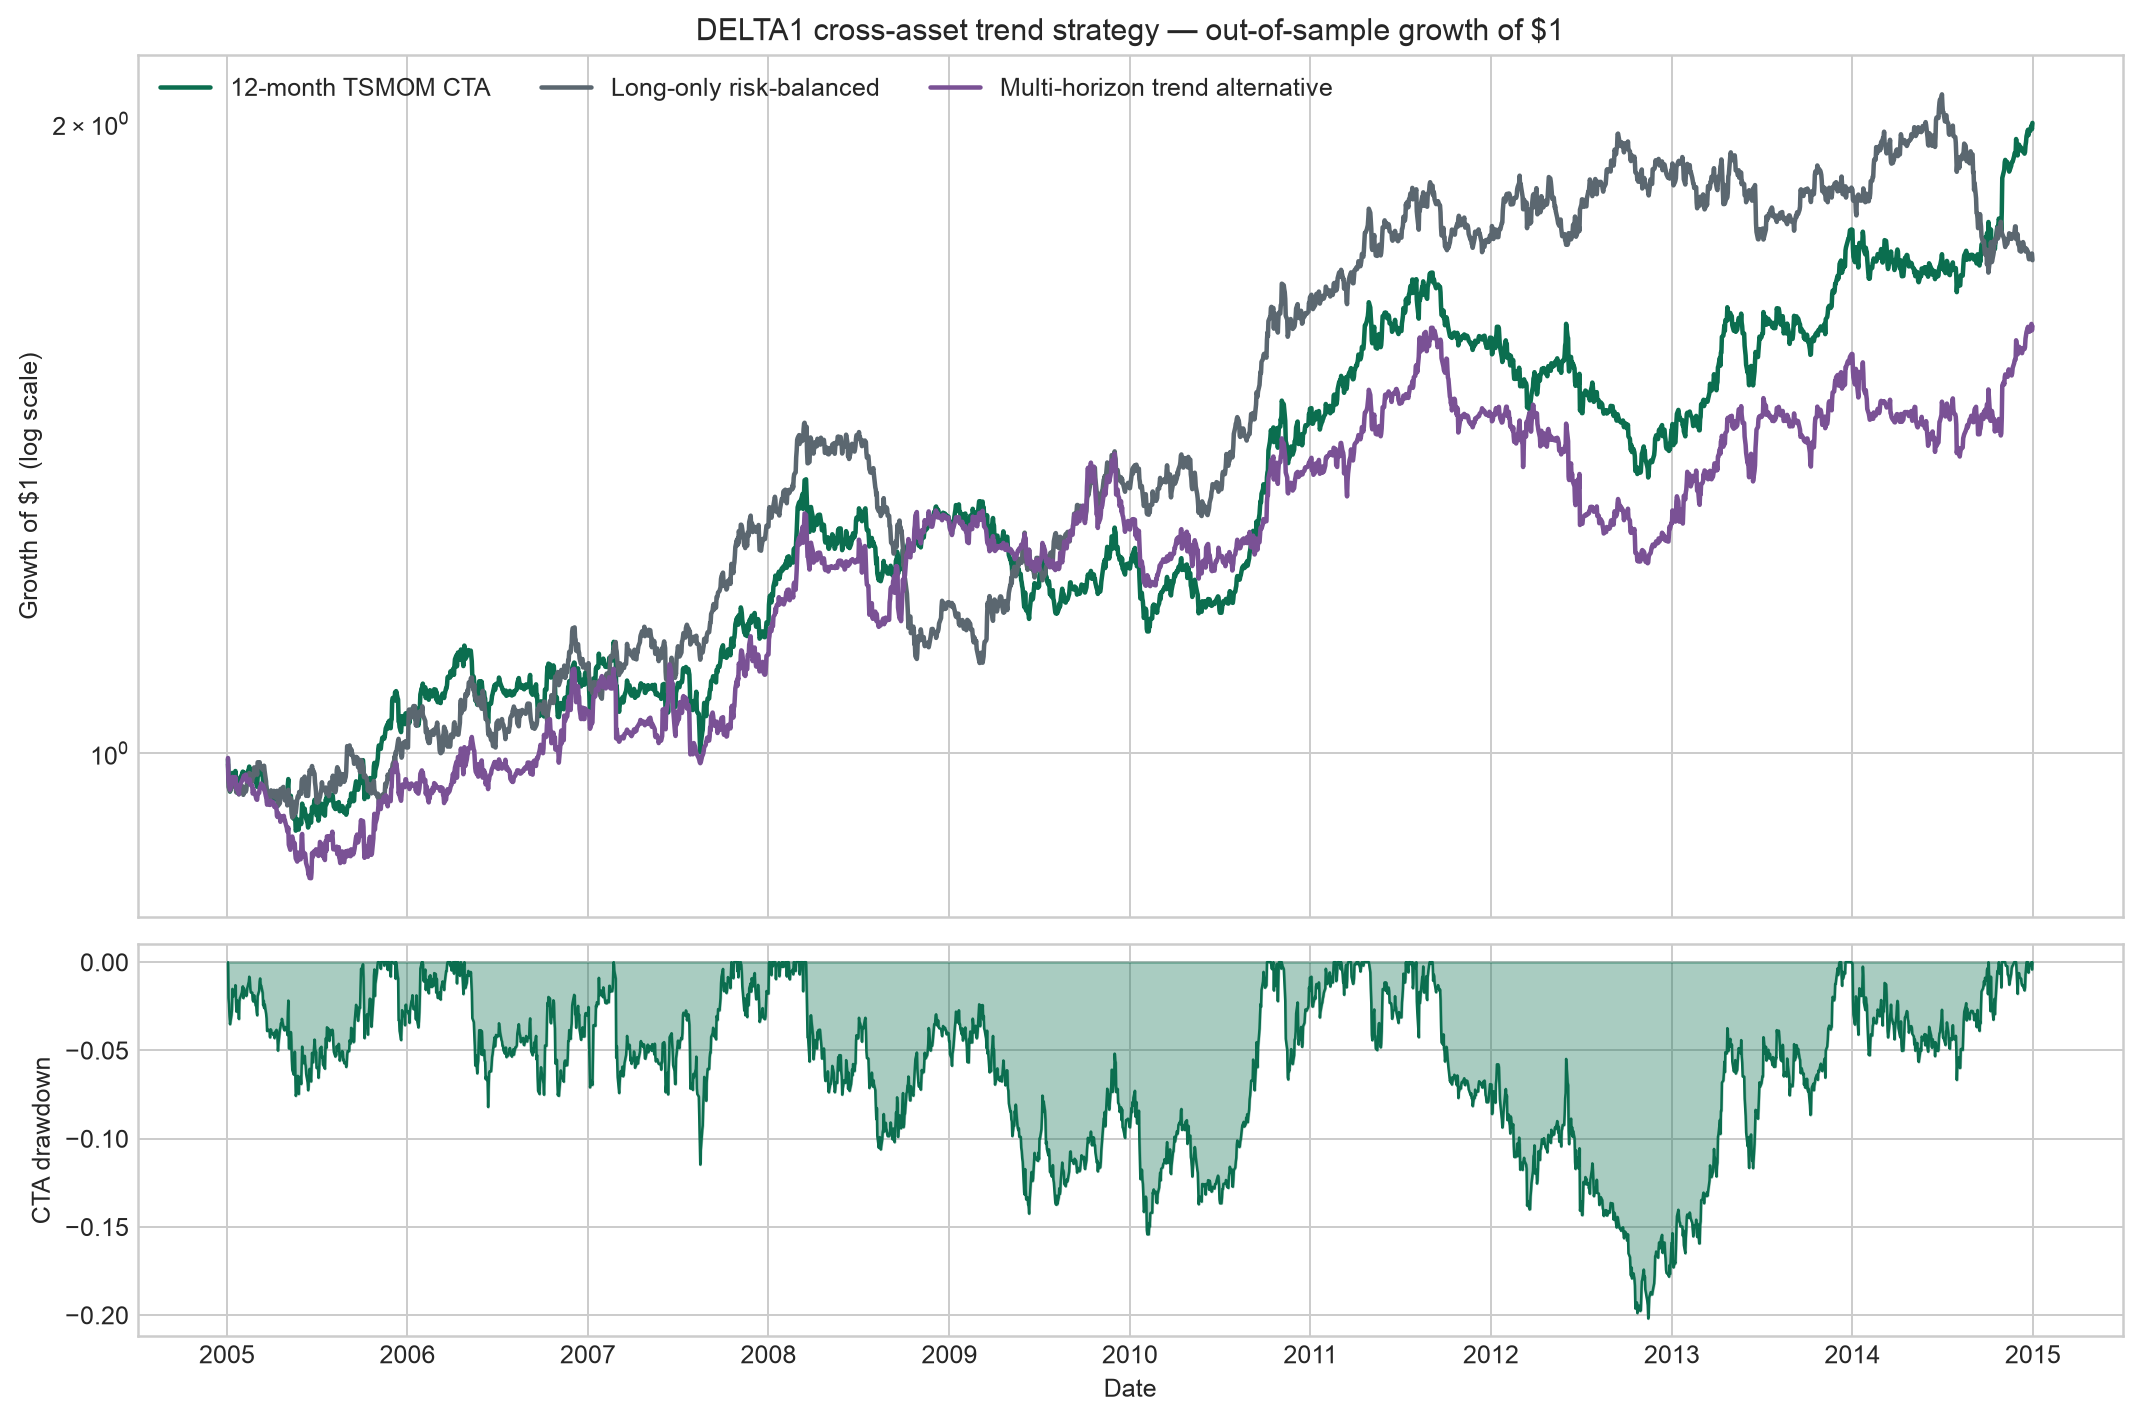

/var/folders/39/8k2n5j154v72pxxr9yybgbth0000gn/T/ipykernel_33642/789552445.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
display(Image(filename=str(OUTPUT_DIR / "performance.png")))

yearly = pd.read_csv(OUTPUT_DIR / "yearly_returns.csv", index_col="Year")
ax = yearly.plot(kind="bar", figsize=(12, 4.8), color=["#0B6E4F", "#5B6770", "#7A5195"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Calendar-year net returns in the out-of-sample window")
ax.set_ylabel("Return")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

In [5]:
class_contrib = contribution_by_class(strategy, config)
display(class_contrib.style.format("{:.2%}"))

monthly = strategy.daily.loc[config.oos_start:, "net_return"].resample("ME").apply(lambda x: (1+x).prod()-1)
rolling_sharpe = monthly.rolling(36).mean() / monthly.rolling(36).std() * np.sqrt(12)
ax = rolling_sharpe.plot(figsize=(11, 3.5), color="#0B6E4F", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rolling 36-month Sharpe — performance is time-varying")
ax.set_ylabel("Sharpe (rf=0)")
plt.tight_layout()
plt.show()

,Annualized mean contribution,Annualized standalone volatility
Equity indices,3.49%,5.61%
Government bonds,2.16%,5.40%
G10 FX,-0.62%,4.33%
Commodities,2.38%,4.55%


/var/folders/39/8k2n5j154v72pxxr9yybgbth0000gn/T/ipykernel_33642/12042477.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Interpretation

The simple 12-month CTA is the preferred specification. Its value is not a smooth equity curve: trend following can lose during rapid reversals and range-bound markets. Its portfolio role comes from directional flexibility and diversification across unrelated futures markets. In this sample, it was positive in 2008 while the long-only benchmark was negative, but it also had losing years.

Asset-class contribution should be read as historical attribution, not a forecast. A broad contribution base is healthier than reliance on a single contract or class.

## 5. Robustness rather than in-sample optimisation

The next table varies only two economically interpretable choices:

- signal horizons: short/medium, balanced, medium/long, and the pre-specified 12-month rule;
- transaction costs: zero, base case, and twice the base case.

This is a sensitivity check; the primary strategy remains the literature-specified 12-month rule.

In [6]:
robust_display = robustness.copy()
for column in ["CAGR", "Volatility", "Max drawdown"]:
    robust_display[column] = robust_display[column].map(lambda x: f"{x:.2%}")
robust_display["Sharpe"] = robust_display["Sharpe"].map(lambda x: f"{x:.2f}")
display(robust_display)

pivot = robustness.pivot(index="Signal", columns="Cost multiple", values="Sharpe")
ax = pivot.plot(kind="bar", figsize=(11, 4.5), color=["#9ED9CC", "#0B6E4F", "#083D2E"])
ax.set_title("OOS Sharpe sensitivity to trend horizon and trading costs")
ax.set_ylabel("Sharpe (rf=0)")
ax.set_xlabel("")
ax.legend(title="Cost multiple", frameon=False)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,Signal,Cost multiple,CAGR,Volatility,Sharpe,Max drawdown
0,"Short/medium (1m, 3m)",0.0000,3.34%,11.39%,0.35,-15.90%
1,"Short/medium (1m, 3m)",1.0000,3.00%,11.38%,0.32,-16.33%
2,"Short/medium (1m, 3m)",2.0000,2.67%,11.38%,0.29,-16.76%
3,"Balanced (1m, 3m, 12m)",0.0000,4.95%,11.42%,0.48,-22.49%
4,"Balanced (1m, 3m, 12m)",1.0000,4.65%,11.41%,0.46,-22.83%
5,"Balanced (1m, 3m, 12m)",2.0000,4.34%,11.41%,0.43,-23.17%
6,"Medium/long (3m, 6m, 12m)",0.0000,5.92%,11.10%,0.57,-22.36%
7,"Medium/long (3m, 6m, 12m)",1.0000,5.70%,11.10%,0.56,-22.56%
8,"Medium/long (3m, 6m, 12m)",2.0000,5.48%,11.10%,0.54,-22.77%
9,Classic (12m),0.0000,7.08%,10.69%,0.69,-20.03%


/var/folders/39/8k2n5j154v72pxxr9yybgbth0000gn/T/ipykernel_33642/3652660614.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Limitations and next steps

1. **Historical endpoint.** The provided futures data stops in 2014. A production decision needs post-2014 and live paper-trading validation.
2. **Continuous-contract abstraction.** `_CCB` files are research series. A deployable version must define an actual roll calendar, expiry selection, and roll slippage using individual contracts.
3. **Costs and capacity.** Half a tick plus commission is transparent but simplified. Market impact depends on order size, time of day, liquidity, and contract.
4. **Universe selection.** The USD-only rule is defined for clean P&L accounting. Adding non-USD contracts requires point-in-time FX conversion and may improve diversification.
5. **Collateral and funding.** Cash yield, variation margin, broker haircuts, and financing are omitted.
6. **Backtest inference.** Ten years is enough for the case requirement but still a small number of independent trend episodes. Results should not be treated as a precise expected return.
7. **Operational risk.** Limit moves, exchange holidays, stale prices, and missing data need explicit live controls.

Useful extensions are a contract-level roll engine, bid/ask and volume-aware cost model, post-2014 validation, and a paper portfolio with broker margin checks. Those additions improve implementation realism without changing the core signal.

## 7. Key takeaways

- A one-line, literature-backed trend signal can be turned into a diversified CTA with explicit risk and execution rules.
- Correct futures P&L accounting matters: use price changes × point value on additive back-adjusted series.
- The out-of-sample period spans more than ten years and all predictors are lagged.
- The 12-month rule was stronger here than the more complex multi-horizon alternative, while remaining profitable under doubled cost assumptions.
- The result is promising historical evidence, not deployment-ready proof; roll mechanics and newer data are the highest-priority next steps.